# Series de tiempo y detección de anomalías en vigilancia centinela


Datos: `vigilancia_centinela.xlsx` — consultas diarias por eventos respiratorios y
cardiovasculares, junto con variables ambientales (enero 2023 – abril 2024).

---

### ¿Qué vamos a lograr?

Al terminar este cuaderno usted podrá:

1. Reconocer los patrones básicos de una serie de tiempo diaria de eventos en salud.
2. Explicar por qué **no todos los días se comportan igual**.
3. Calcular un **valor esperado** para cada día.
4. Convertir la diferencia entre lo observado y lo esperado en una **puntuación de anomalía**.
5. Construir una **tabla de días candidatos a investigación**.

> **Importante desde el inicio:** la detección automática de anomalías **no reemplaza** el
> análisis epidemiológico. Es una herramienta que ayuda a decidir **qué días mirar primero**.

## 1. ¿Qué es una serie de tiempo?

Imagine que cada noche, al cerrar el servicio, alguien anota en un cuaderno:

> *"Hoy atendimos 78 personas."*

Al cabo de un año usted tiene una lista larguísima de números, uno por día, en orden.
**Eso es una serie de tiempo:**

> **Serie de tiempo = una variable observada repetidamente a través del tiempo.**

Lo importante no es cada número por separado, sino **el orden**. Si usted revuelve las
filas de una base de pacientes, casi nada se pierde. Si revuelve los días de una serie
de tiempo, **se pierde toda la información**.

### Cuatro palabras que necesitamos (y solo cuatro)

| Concepto | En lenguaje cotidiano | Ejemplo en vigilancia |
|---|---|---|
| **Nivel** | ¿Alrededor de qué número se mueve la serie? | "Atendemos alrededor de 80 personas al día" |
| **Tendencia** | ¿Sube o baja con el paso de los meses? | "Desde marzo venimos atendiendo cada vez más" |
| **Estacionalidad** | ¿Hay un patrón que se repite? | "Los lunes siempre hay más consultas que los domingos" |
| **Anomalía** | Un día que se sale de lo habitual | "Ese martes atendimos el doble de lo normal" |

### Tres preguntas para tener en mente

- ❓ **¿Todos los días se comportan igual?**
- ❓ **¿Los lunes se parecen a los domingos?**
- ❓ **¿Cómo sabemos cuándo un valor es realmente extraño?**

Las responderemos **mirando los datos**, no con fórmulas.

## 2. Instalación mínima

Solo necesitamos dos cosas que quizá no estén instaladas:

- **`darts`** → la librería de series de tiempo que usaremos.
- **`openpyxl`** → para leer archivos de Excel.

La siguiente celda **instala únicamente si hace falta**, así que puede ejecutarla sin miedo.

In [1]:
# Instala solo si Darts no está disponible (por ejemplo, en Google Colab)
import importlib.util

FALTA_DARTS = importlib.util.find_spec("darts") is None

if FALTA_DARTS:
    %pip install -q darts openpyxl
    print("Instalación finalizada. Si aparece un aviso, reinicie el kernel y ejecute de nuevo.")
else:
    print("✓ Darts ya está instalado: no es necesario instalar nada")

✓ Darts ya está instalado: no es necesario instalar nada


In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Herramientas de Darts que usaremos (y ninguna más)
import darts
from darts import TimeSeries
from darts.models import NaiveSeasonal
from darts.metrics import mae, rmse
from darts.ad import NormScorer

# Estilo de los gráficos: grandes y legibles para proyectar en clase
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.30
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

import matplotlib

print("pandas     :", pd.__version__)
print("numpy      :", np.__version__)
print("matplotlib :", matplotlib.__version__)
print("darts      :", darts.__version__)
print("\n✓ Todas las librerías se importaron correctamente")

pandas     : 2.3.3
numpy      : 2.4.4
matplotlib : 3.10.0
darts      : 0.43.0

✓ Todas las librerías se importaron correctamente


## 3. Parámetros del taller

Esta es **la única celda que el docente necesita modificar**. Todo el resto del cuaderno
se adapta automáticamente.

In [3]:
ARCHIVO           = "vigilancia_centinela.xlsx"
HOJA              = "todo"      # alternativa: "sin chapinero"
VARIABLE_OBJETIVO = "total"     # alternativas: "resp", "cardio", "infe", "pm2.5", ...

# Parámetros del análisis (se explican más adelante)
ESTACIONALIDAD    = 7    # datos diarios -> el ciclo natural es la semana
DIAS_PRUEBA       = 60   # últimos días reservados para evaluar el modelo
DIAS_APRENDIZAJE  = 60   # días iniciales usados solo para aprender, sin puntuar
PERCENTIL_UMBRAL  = 95   # desde qué percentil marcamos un día como candidato

print(f"Hoja seleccionada   : {HOJA}")
print(f"Variable a analizar : {VARIABLE_OBJETIVO}")

Hoja seleccionada   : todo
Variable a analizar : total


### 3.1 Buscar el archivo de Excel

El cuaderno busca `vigilancia_centinela.xlsx` **en su propia carpeta**. Si no lo encuentra
allí, revisa algunas carpetas cercanas del proyecto. **En ningún momento modifica el Excel.**

In [4]:
def buscar_archivo(nombre=ARCHIVO):
    """Busca el Excel junto al cuaderno y, si no está, en carpetas cercanas."""
    candidatos = [
        Path(nombre),                                   # misma carpeta (caso habitual)
        Path("..") / nombre,
        Path("03_datos") / "14_var" / nombre,
        Path("..") / "03_datos" / "14_var" / nombre,
    ]
    for ruta in candidatos:
        if ruta.exists():
            return ruta

    # Último recurso: búsqueda acotada hacia arriba (máximo dos niveles)
    for base in [Path.cwd(), *list(Path.cwd().parents)[:2]]:
        encontrados = list(base.rglob(nombre))
        if encontrados:
            return encontrados[0]

    raise FileNotFoundError(
        f"No se encontró '{nombre}'. Colóquelo en la misma carpeta que este cuaderno."
    )


RUTA = buscar_archivo()
print("✓ Archivo encontrado en:")
print(" ", RUTA.resolve())
print("\nHojas disponibles:", pd.ExcelFile(RUTA).sheet_names)

✓ Archivo encontrado en:
  C:\Users\wsand\Documentos\GitHub\Series-de-Tiempo\03_datos\14_var\vigilancia_centinela.xlsx

Hojas disponibles: ['todo', 'sin chapinero']


### 3.2 Cargar y ordenar los datos

Tres cuidados que **siempre** valen la pena en una serie de tiempo real:

1. **Limpiar los nombres de las columnas** (`.str.strip()`): en este archivo hay columnas
   guardadas como `"asma "` y `"precipitacion "`, con un espacio invisible al final.
2. **Convertir `fecha` a formato de fecha**, para que Python entienda el calendario.
3. **Ordenar cronológicamente**: en una serie de tiempo el orden *es* la información.

> ⚠️ El archivo trae una columna `dia_sem`, pero **no la usaremos**: la recalcularemos
> nosotros mismos a partir de `fecha` (sección 6).

In [5]:
def cargar_hoja(hoja):
    """Lee una hoja del Excel, limpia nombres, convierte fechas y ordena."""
    datos = pd.read_excel(RUTA, sheet_name=hoja)
    datos.columns = datos.columns.str.strip()          # 'asma ' -> 'asma'
    datos["fecha"] = pd.to_datetime(datos["fecha"])
    datos = datos.sort_values("fecha").reset_index(drop=True)
    return datos


df = cargar_hoja(HOJA)

print(f"Hoja cargada : '{HOJA}'")
print(f"Filas        : {len(df)}")
print(f"Columnas     : {list(df.columns)}")

Hoja cargada : 'todo'
Filas        : 462
Columnas     : ['fecha', 'dia_sem', 'resp', 'asma', 'EPOC', 'infe', 'otrasresp', 'ECV', 'EIC', 'otrascardio', 'cardio', 'total', 'pm10', 'pm2.5', 'temperatura', 'precipitacion']


### 3.3 Revisión de calidad: ¿podemos confiar en esta serie?

Antes de graficar nada, revisamos cuatro cosas. **No borramos ni corregimos nada en
silencio**: solamente informamos.

In [6]:
print("REVISIÓN DE CALIDAD DE LA SERIE")
print("=" * 58)

# 1) Fechas duplicadas
n_duplicadas = int(df["fecha"].duplicated().sum())
if n_duplicadas == 0:
    print("✓ No existen fechas duplicadas")
else:
    print(f"⚠ Hay {n_duplicadas} fechas duplicadas (revisar antes de continuar)")

# 2) Extensión de la serie
inicio, fin = df["fecha"].min(), df["fecha"].max()
print(f"✓ La serie contiene {len(df)} días, del {inicio:%d/%m/%Y} al {fin:%d/%m/%Y}")

# 3) Días faltantes del calendario
calendario = pd.date_range(inicio, fin, freq="D")
faltantes = calendario.difference(df["fecha"])
if len(faltantes) == 0:
    print("✓ Frecuencia detectada: diaria, sin días faltantes")
else:
    print(f"⚠ Faltan {len(faltantes)} días del calendario. Primeros casos:")
    print("  ", list(faltantes[:5]))

# 4) Valores faltantes
n_vacios = int(df.isna().sum().sum())
if n_vacios == 0:
    print("✓ No hay valores faltantes en ninguna columna")
else:
    print(f"⚠ Hay {n_vacios} valores faltantes:")
    print(df.isna().sum()[df.isna().sum() > 0].to_string())

print("=" * 58)
print("Ningún registro fue eliminado ni modificado.")

REVISIÓN DE CALIDAD DE LA SERIE
✓ No existen fechas duplicadas
✓ La serie contiene 462 días, del 01/01/2023 al 06/04/2024
✓ Frecuencia detectada: diaria, sin días faltantes
✓ No hay valores faltantes en ninguna columna
Ningún registro fue eliminado ni modificado.


## 4. Conocer primero los datos

### ¿Qué significa cada columna?

**Eventos respiratorios**

| Columna | Significado |
|---|---|
| `asma` | Consultas por asma |
| `EPOC` | Enfermedad pulmonar obstructiva crónica |
| `infe` | Infecciones respiratorias |
| `otrasresp` | Otras causas respiratorias |
| `resp` | **Total respiratorio** (suma de las cuatro anteriores) |

**Eventos cardiovasculares**

| Columna | Significado |
|---|---|
| `ECV` | Enfermedad cerebrovascular |
| `EIC` | Enfermedad isquémica del corazón |
| `otrascardio` | Otras causas cardiovasculares |
| `cardio` | **Total cardiovascular** (suma de las tres anteriores) |

**Variables ambientales**

| Columna | Significado |
|---|---|
| `pm10` | Material particulado de 10 micras (µg/m³) |
| `pm2.5` | Material particulado fino de 2.5 micras (µg/m³) |
| `temperatura` | Temperatura promedio del día (°C) |
| `precipitacion` | Lluvia del día (mm) |

Y finalmente: `total` = `resp` + `cardio`.

In [7]:
df.head()

,fecha,dia_sem,resp,asma,EPOC,infe,otrasresp,ECV,EIC,otrascardio,cardio,total,pm10,pm2.5,temperatura,precipitacion
0,2023-01-01,2023-01-01,16,1,4,7,4,0,0,4,4,20,34.928212,27.345993,14.657143,6.417647
1,2023-01-02,2023-01-02,36,4,3,24,5,0,1,12,13,49,21.605515,13.175385,14.264286,4.329412
2,2023-01-03,2023-01-03,29,2,8,16,3,1,2,13,16,45,22.431935,11.508536,14.157143,5.323529
3,2023-01-04,2023-01-04,23,4,3,8,8,0,0,12,12,35,27.948804,14.005474,14.557143,0.294118
4,2023-01-05,2023-01-05,32,5,0,27,0,4,1,15,20,52,27.770948,16.159166,14.635714,0.388235


### 4.1 Comprobar que las sumas cuadran

Verificamos que las tres identidades del sistema de información se cumplan **todos los
días**. Si no cuadraran, el problema estaría en los datos y no en el modelo.

In [8]:
def comprobar_suma(total, partes):
    """Verifica que una columna sea exactamente la suma de sus componentes."""
    diferencia = (df[total] - df[partes].sum(axis=1)).abs()
    formula = f"{total} = " + " + ".join(partes)
    if diferencia.max() == 0:
        print(f"✓ {formula}")
    else:
        print(f"⚠ {formula}  → no cuadra en {int((diferencia > 0).sum())} días "
              f"(diferencia máxima: {diferencia.max():.0f})")


comprobar_suma("resp",   ["asma", "EPOC", "infe", "otrasresp"])
comprobar_suma("cardio", ["ECV", "EIC", "otrascardio"])
comprobar_suma("total",  ["resp", "cardio"])

✓ resp = asma + EPOC + infe + otrasresp
✓ cardio = ECV + EIC + otrascardio
✓ total = resp + cardio


### 4.2 Un resumen corto (sin saturarnos de estadísticas)

Solo nos interesan cinco números por variable: cuántos días hay, el promedio, el mínimo,
la mediana y el máximo.

In [9]:
columnas_resumen = ["total", "resp", "cardio", "pm10", "pm2.5", "temperatura", "precipitacion"]

# Si el docente eligió otra variable, la añadimos al resumen
if VARIABLE_OBJETIVO not in columnas_resumen:
    columnas_resumen.insert(0, VARIABLE_OBJETIVO)

resumen = df[columnas_resumen].describe().T[["count", "mean", "min", "50%", "max"]]
resumen.columns = ["Días", "Promedio", "Mínimo", "Mediana", "Máximo"]
resumen.round(1)

,Días,Promedio,Mínimo,Mediana,Máximo
total,462.0,79.4,20.0,78.0,156.0
resp,462.0,55.3,12.0,53.0,134.0
cardio,462.0,24.1,4.0,24.0,45.0
pm10,462.0,32.5,8.6,30.1,80.5
pm2.5,462.0,17.0,3.9,15.5,47.8
temperatura,462.0,15.5,12.6,15.5,17.6
precipitacion,462.0,2.3,0.0,0.4,31.0


## 5. Primera visualización: mirar la serie

Antes de cualquier modelo, **hay que mirar el dibujo**. Graficamos dos cosas:

- la **línea diaria**: lo que ocurrió exactamente cada día (sube y baja mucho);
- la **media móvil de 7 días**: el promedio de cada día con los tres anteriores y los tres
  siguientes. Es como mirar la serie "de lejos": desaparece el ruido del día a día y queda
  el **comportamiento general**.

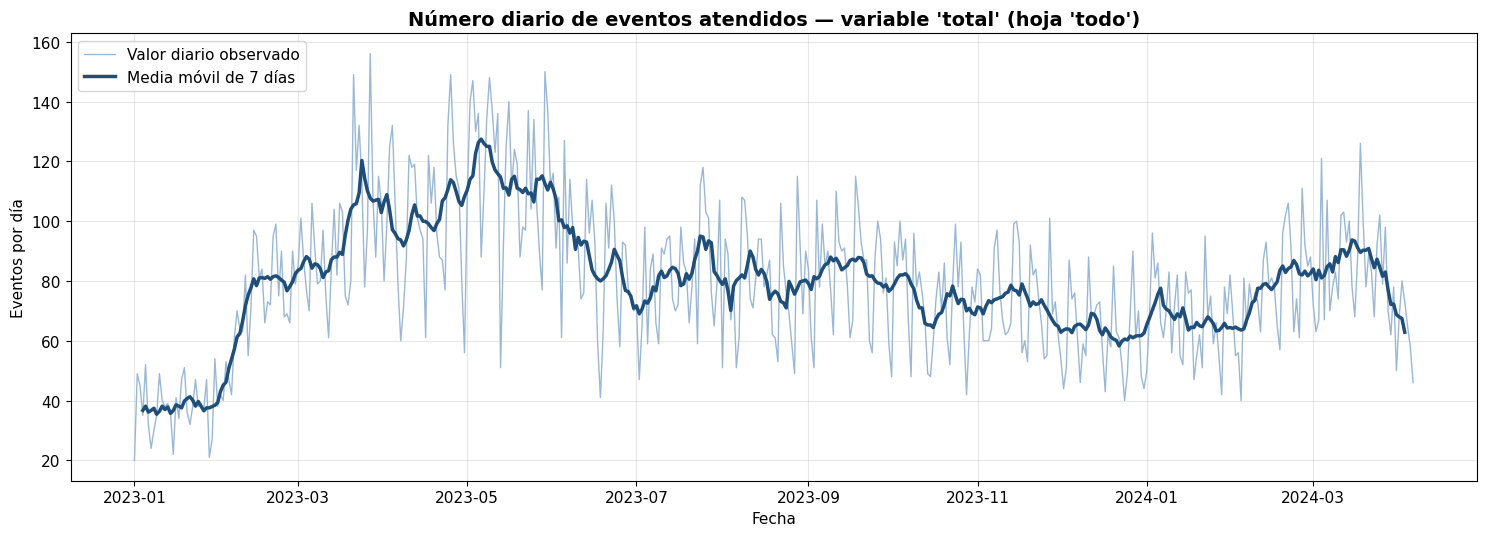

In [10]:
# Media móvil de 7 días: promedio de cada día con su semana alrededor
df["media_movil_7"] = df[VARIABLE_OBJETIVO].rolling(window=7, center=True).mean()

fig, ax = plt.subplots(figsize=(15, 5.5))

ax.plot(df["fecha"], df[VARIABLE_OBJETIVO],
        color="#9ab8d6", linewidth=1.0, label="Valor diario observado")
ax.plot(df["fecha"], df["media_movil_7"],
        color="#1f4e79", linewidth=2.5, label="Media móvil de 7 días")

ax.set_title(f"Número diario de eventos atendidos — variable '{VARIABLE_OBJETIVO}' (hoja '{HOJA}')")
ax.set_xlabel("Fecha")
ax.set_ylabel("Eventos por día")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

### ❓ Pregunta de interpretación

Mire el gráfico durante un minuto y responda con sus palabras:

1. ¿Alrededor de qué número se mueve la serie? (**nivel**)
2. ¿La línea azul oscura sube, baja o se mantiene a lo largo del año? (**tendencia**)
3. ¿Por qué la línea clara "tiembla" tanto mientras la oscura es suave?
4. ¿Ve algún día que se dispare muy por encima o muy por debajo del resto?

> Esa última pregunta es justamente la que vamos a responder de manera sistemática.

## 6. Descubrir la estacionalidad semanal

Volvamos a la pregunta inicial: **¿los lunes se parecen a los domingos?**

Para responder necesitamos saber qué día de la semana fue cada fecha. El archivo trae una
columna `dia_sem`, pero **no confiaremos en ella**: la construimos de nuevo a partir de
`fecha`, que es el dato original y verificable.

In [11]:
# Nombres en español, independientes del idioma del computador
DIAS_ES = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]

df["dia_semana"]    = df["fecha"].dt.dayofweek          # 0 = Lunes ... 6 = Domingo
df["nombre_dia"]    = df["dia_semana"].map(lambda i: DIAS_ES[i])
df["fin_de_semana"] = df["dia_semana"].isin([5, 6])     # sábado y domingo

df[["fecha", "nombre_dia", "fin_de_semana", VARIABLE_OBJETIVO]].head(8)

,fecha,nombre_dia,fin_de_semana,total
0,2023-01-01,Domingo,True,20
1,2023-01-02,Lunes,False,49
2,2023-01-03,Martes,False,45
3,2023-01-04,Miércoles,False,35
4,2023-01-05,Jueves,False,52
5,2023-01-06,Viernes,False,32
6,2023-01-07,Sábado,True,24
7,2023-01-08,Domingo,True,30


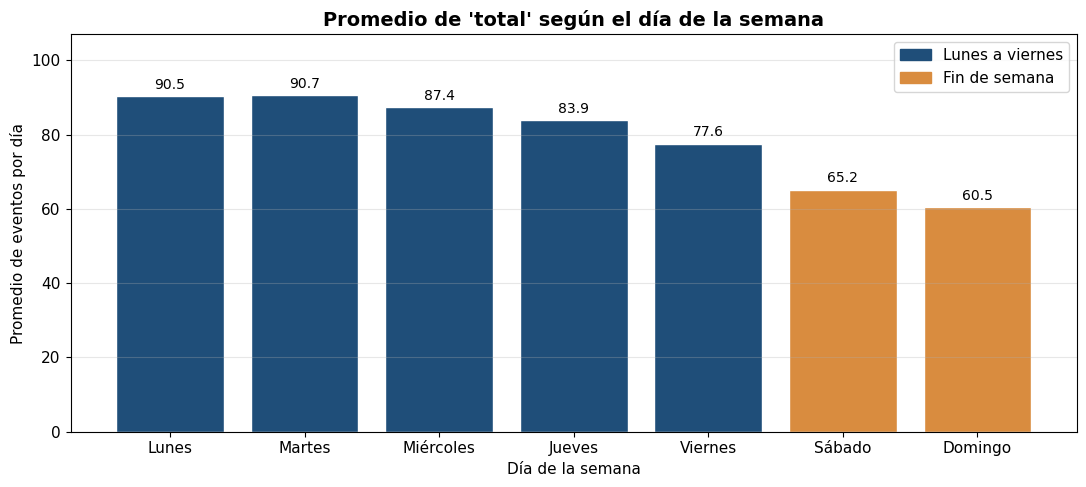

Día con más eventos  : Martes (90.7)
Día con menos eventos: Domingo (60.5)
Diferencia           : 30.2 eventos (50% más)


In [12]:
promedio_dia = df.groupby("dia_semana")[VARIABLE_OBJETIVO].mean()

colores = ["#1f4e79"] * 5 + ["#d98c3f"] * 2   # entre semana vs fin de semana

fig, ax = plt.subplots(figsize=(11, 5))
barras = ax.bar(DIAS_ES, promedio_dia.values, color=colores, edgecolor="white")
ax.bar_label(barras, fmt="%.1f", padding=3, fontsize=10)

ax.set_title(f"Promedio de '{VARIABLE_OBJETIVO}' según el día de la semana")
ax.set_xlabel("Día de la semana")
ax.set_ylabel("Promedio de eventos por día")
ax.set_ylim(0, promedio_dia.max() * 1.18)
ax.grid(axis="x", visible=False)

# Leyenda explícita para los dos colores
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#1f4e79", label="Lunes a viernes"),
                   Patch(color="#d98c3f", label="Fin de semana")],
          loc="upper right")
plt.tight_layout()
plt.show()

print(f"Día con más eventos  : {DIAS_ES[int(promedio_dia.idxmax())]} ({promedio_dia.max():.1f})")
print(f"Día con menos eventos: {DIAS_ES[int(promedio_dia.idxmin())]} ({promedio_dia.min():.1f})")
print(f"Diferencia           : {promedio_dia.max() - promedio_dia.min():.1f} eventos "
      f"({100 * (promedio_dia.max() / promedio_dia.min() - 1):.0f}% más)")

### ¿Qué acabamos de descubrir?

**No todos los días se comportan igual.** Las barras no tienen la misma altura: existe un
patrón que **se repite cada siete días**. Eso es la **estacionalidad semanal**.

Y tiene una consecuencia práctica enorme para la vigilancia:

> Comparar un domingo con un lunes es comparar peras con manzanas.
> Un domingo con muchos eventos puede ser **rarísimo**, aunque su número sea más bajo que
> el de un lunes cualquiera.

Por eso, cuando más adelante calculemos el "valor esperado" de un día, lo compararemos con
**el mismo día de la semana**, no con el día anterior.

## 7. Introducir Darts

Hasta aquí trabajamos con una tabla de pandas. **Darts** es una librería especializada en
series de tiempo que usa un objeto propio llamado `TimeSeries`.

¿Para qué sirve? Un `TimeSeries` guarda junto **el valor y su fecha**, y sabe que los datos
son diarios (`freq="D"`). Gracias a esa estructura común, decenas de métodos distintos
—desde el más simple hasta el más sofisticado— se usan **exactamente igual**:
`.fit()` para aprender y `.predict()` para pronosticar.

In [13]:
serie = TimeSeries.from_dataframe(
    df,
    time_col="fecha",               # columna de tiempo
    value_cols=VARIABLE_OBJETIVO,   # columna de valores
    freq="D",                       # D = frecuencia diaria
)

print("Serie creada con Darts")
print("-" * 40)
print(f"Variable      : {VARIABLE_OBJETIVO}")
print(f"Primer día    : {serie.start_time():%d/%m/%Y}")
print(f"Último día    : {serie.end_time():%d/%m/%Y}")
print(f"Número de días: {len(serie)}")
print(f"Frecuencia    : {serie.freq_str}  (D = diaria)")

Serie creada con Darts
----------------------------------------
Variable      : total
Primer día    : 01/01/2023
Último día    : 06/04/2024
Número de días: 462
Frecuencia    : D  (D = diaria)


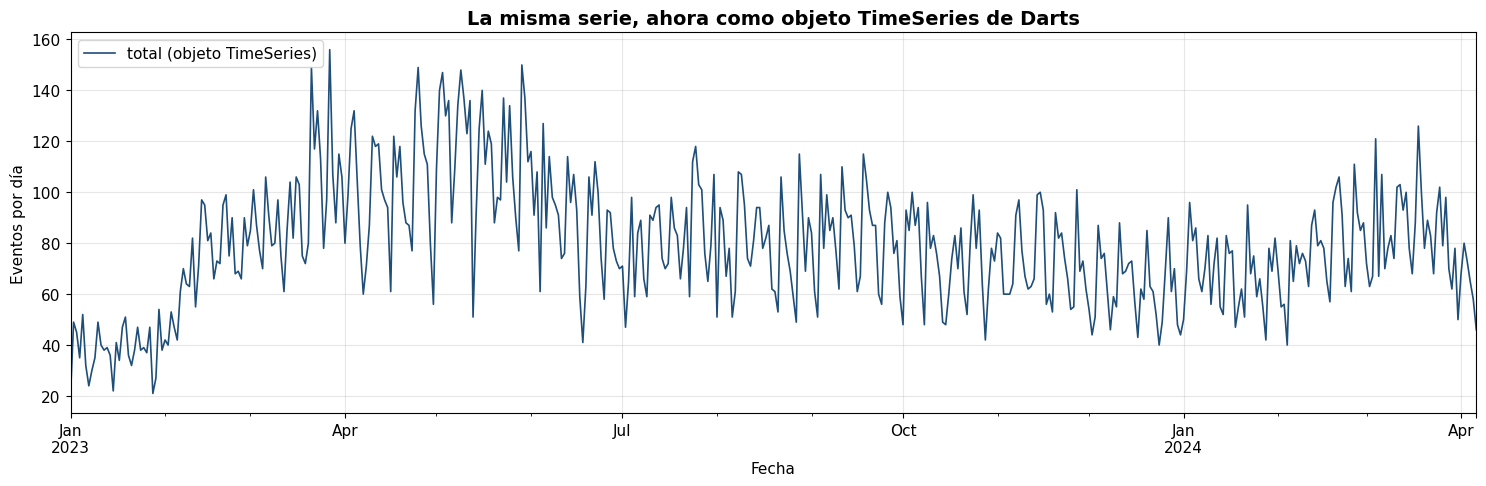

In [14]:
fig, ax = plt.subplots(figsize=(15, 5))
serie.plot(ax=ax, label=f"{VARIABLE_OBJETIVO} (objeto TimeSeries)", color="#1f4e79", lw=1.2)
ax.set_title("La misma serie, ahora como objeto TimeSeries de Darts")
ax.set_xlabel("Fecha")
ax.set_ylabel("Eventos por día")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

> 📌 **Dato clave para el resto del taller:** como los datos son **diarios** y ya vimos que
> los días de la semana se comportan distinto, la estacionalidad natural de esta serie es de
> **7 días**. Ese número (`ESTACIONALIDAD = 7`) es el que usaremos de aquí en adelante.

## 8. Un modelo extremadamente sencillo

Antes de escribir una sola línea de código, la idea en una frase:

> **Para estimar lo que debería ocurrir hoy, utilizaremos como referencia el valor
> observado el mismo día de la semana anterior.**

Es decir: para saber qué esperar de **este lunes**, miramos **el lunes pasado**.
Para este domingo, el domingo pasado. Nada más.

Eso es exactamente lo que hace `NaiveSeasonal(K=7)` en Darts. Se llama "ingenuo" (*naive*)
porque es la regla más simple posible... y precisamente por eso es un excelente punto de
partida: **cualquier modelo más complejo tiene que demostrar que le gana a esta regla.**

### Entrenamiento y prueba

Partimos la serie en dos:

- **Entrenamiento**: todo lo anterior, lo que el modelo puede ver.
- **Prueba**: los últimos 60 días, que escondemos para evaluar si acierta.

Es como tapar el final del cuaderno y preguntar: *¿qué habrías dicho tú?*

In [15]:
serie_entrenamiento = serie[:-DIAS_PRUEBA]
serie_prueba        = serie[-DIAS_PRUEBA:]

print(f"Entrenamiento: {len(serie_entrenamiento)} días "
      f"({serie_entrenamiento.start_time():%d/%m/%Y} a {serie_entrenamiento.end_time():%d/%m/%Y})")
print(f"Prueba       : {len(serie_prueba)} días "
      f"({serie_prueba.start_time():%d/%m/%Y} a {serie_prueba.end_time():%d/%m/%Y})")

Entrenamiento: 402 días (01/01/2023 a 06/02/2024)
Prueba       : 60 días (07/02/2024 a 06/04/2024)


In [16]:
modelo = NaiveSeasonal(K=ESTACIONALIDAD)   # K = 7 -> mismo día de la semana anterior
modelo.fit(serie_entrenamiento)

pronostico = modelo.predict(DIAS_PRUEBA)

print(f"✓ Modelo entrenado y pronóstico de {DIAS_PRUEBA} días generado")

✓ Modelo entrenado y pronóstico de 60 días generado


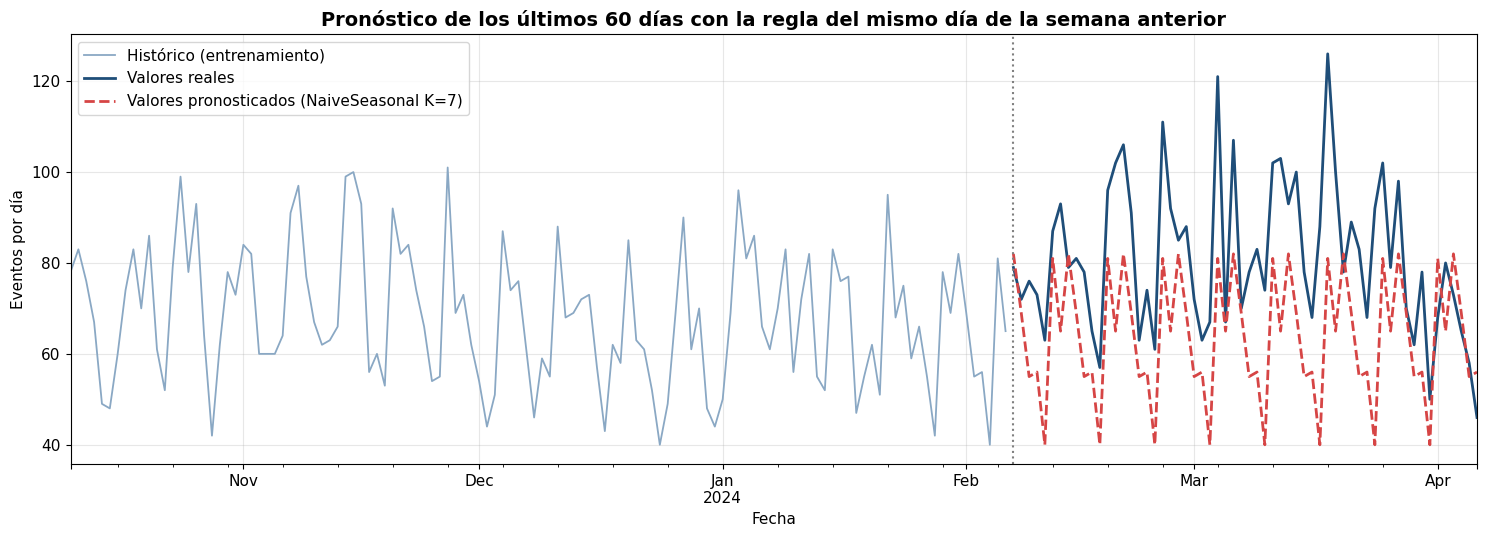

In [17]:
fig, ax = plt.subplots(figsize=(15, 5.5))

# Solo los últimos 120 días del histórico, para que se vea con claridad
serie_entrenamiento[-120:].plot(ax=ax, label="Histórico (entrenamiento)", color="#8aa8c4", lw=1.3)
serie_prueba.plot(ax=ax, label="Valores reales", color="#1f4e79", lw=2.0)
pronostico.plot(ax=ax, label="Valores pronosticados (NaiveSeasonal K=7)",
                color="#d64545", lw=2.0, linestyle="--")

ax.axvline(serie_prueba.start_time(), color="gray", linestyle=":", lw=1.5)
ax.set_title(f"Pronóstico de los últimos {DIAS_PRUEBA} días con la regla del mismo día de la semana anterior")
ax.set_xlabel("Fecha")
ax.set_ylabel("Eventos por día")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

### ¿Qué tan bien le fue? Dos métricas fáciles de explicar

- **MAE** (error absoluto medio): *"en promedio nos equivocamos por X eventos al día"*.
  Se lee en las mismas unidades de la serie. Es la más fácil de comunicar.
- **RMSE**: parecido, pero **castiga más los errores grandes**. Si el RMSE es mucho mayor
  que el MAE, significa que hubo algunos días con errores muy grandes.

No vamos a hacer una competencia de modelos. Con estos dos números basta para saber
**qué tan lejos está lo observado de lo esperado**, que es lo que realmente nos interesa.

In [18]:
error_mae  = mae(serie_prueba, pronostico)
error_rmse = rmse(serie_prueba, pronostico)
promedio_prueba = float(serie_prueba.values().mean())

print("EVALUACIÓN DEL MODELO SENCILLO")
print("=" * 58)
print(f"MAE  : {error_mae:6.2f} eventos por día")
print(f"RMSE : {error_rmse:6.2f} eventos por día")
print(f"\nPara poner en contexto: en esos {DIAS_PRUEBA} días se atendieron")
print(f"en promedio {promedio_prueba:.1f} eventos diarios.")
print(f"El error promedio equivale al {100 * error_mae / promedio_prueba:.0f}% del nivel de la serie.")
print("\nEl RMSE es mayor que el MAE: hubo algunos días con errores especialmente grandes.")
print("Esos días son, justamente, los que nos interesan.")

EVALUACIÓN DEL MODELO SENCILLO
MAE  :  18.62 eventos por día
RMSE :  22.25 eventos por día

Para poner en contexto: en esos 60 días se atendieron
en promedio 81.2 eventos diarios.
El error promedio equivale al 23% del nivel de la serie.

El RMSE es mayor que el MAE: hubo algunos días con errores especialmente grandes.
Esos días son, justamente, los que nos interesan.


## 9. Del pronóstico a la anomalía

**Esta es la sección central del taller.**

> **Una anomalía no es simplemente un valor alto. Es un valor que se aleja mucho de lo que
> esperaríamos según el comportamiento habitual de la serie.**

Piénselo así:

| Situación | ¿Es anomalía? |
|---|---|
| Un lunes con 95 consultas, cuando los lunes suelen tener 90 | **No.** Es un lunes normal. |
| Un domingo con 95 consultas, cuando los domingos suelen tener 60 | **Sí.** Es un domingo rarísimo. |

El número es el mismo. Lo que cambia es **lo que esperábamos**.

Por eso el procedimiento tiene siempre la misma forma:

**valor observado**  vs.  **valor esperado**  →  **diferencia**  →  **puntuación**

### Un valor esperado para *cada* día

En la sección anterior pronosticamos 60 días de una sola vez. Ahora necesitamos algo
distinto: un valor esperado para **cada día de la serie**, calculado *como si no
conociéramos el futuro*.

Darts hace esto con `historical_forecasts`: recorre la serie día por día y, en cada fecha,
pronostica **un solo día hacia adelante** usando únicamente la información previa.
Es la simulación honesta de lo que habríamos dicho ese día en la sala de vigilancia.

Los primeros 60 días se reservan para aprender y no reciben puntuación.

In [19]:
valor_esperado = modelo.historical_forecasts(
    serie,
    start=DIAS_APRENDIZAJE,     # empezamos a puntuar después de 60 días de aprendizaje
    start_format="position",
    forecast_horizon=1,         # un solo día hacia adelante
    stride=1,                   # avanzamos día por día
    retrain=True,               # reaprendemos con la información disponible en cada fecha
    last_points_only=True,
    verbose=False,
)

# Recortamos la serie observada al mismo tramo de fechas
valor_observado = serie.slice_intersect(valor_esperado)

print(f"Valores esperados calculados para {len(valor_esperado)} días")
print(f"Desde {valor_esperado.start_time():%d/%m/%Y} hasta {valor_esperado.end_time():%d/%m/%Y}")

# Verificación explícita de que las fechas quedaron alineadas
assert (valor_observado.time_index == valor_esperado.time_index).all()
print("\n✓ Las fechas de la serie real y de la predicción están correctamente alineadas")

Valores esperados calculados para 402 días
Desde 02/03/2023 hasta 06/04/2024

✓ Las fechas de la serie real y de la predicción están correctamente alineadas


### La puntuación de anomalía

Ahora medimos, para cada día, **qué tan lejos quedó lo observado de lo esperado**.

Darts tiene un módulo dedicado a esto (`darts.ad`, de *anomaly detection*). Usaremos el
`NormScorer` con `ord=1`, que es simplemente la **diferencia en valor absoluto**:

> `anomaly_score = |valor observado − valor esperado|`

Sin logaritmos, sin transformaciones. Si un día esperábamos 80 consultas y hubo 130, la
puntuación de ese día es 50.

- **Puntuación pequeña** → el día se comportó como esperábamos.
- **Puntuación grande** → el día se comportó de manera poco habitual.

In [20]:
scorer = NormScorer(ord=1)                                   # diferencia absoluta
scores = scorer.score_from_prediction(valor_observado, valor_esperado)

# Reunimos todo en una tabla fácil de leer
resultados = pd.DataFrame({
    "fecha":         scores.time_index,
    "observado":     valor_observado.values().ravel(),
    "esperado":      valor_esperado.values().ravel(),
    "anomaly_score": scores.values().ravel(),
})
resultados["diferencia"] = resultados["observado"] - resultados["esperado"]

# Añadimos el día de la semana y las variables ambientales de cada fecha
resultados = resultados.merge(
    df[["fecha", "nombre_dia", "pm10", "pm2.5", "temperatura", "precipitacion"]],
    on="fecha", how="left",
)

print(f"Puntuación media : {resultados['anomaly_score'].mean():.1f}")
print(f"Puntuación máxima: {resultados['anomaly_score'].max():.1f}")
resultados.head()

Puntuación media : 14.1
Puntuación máxima: 76.0


,fecha,observado,esperado,anomaly_score,diferencia,nombre_dia,pm10,pm2.5,temperatura,precipitacion
0,2023-03-02,101.0,90.0,11.0,11.0,Jueves,26.044822,15.486193,15.985714,0.658824
1,2023-03-03,87.0,68.0,19.0,19.0,Viernes,23.067572,12.172734,16.221429,0.006250
2,2023-03-04,77.0,69.0,8.0,8.0,Sábado,19.279329,9.257948,15.950000,0.693750
3,2023-03-05,70.0,66.0,4.0,4.0,Domingo,13.789198,7.031115,15.450000,3.337500
4,2023-03-06,106.0,90.0,16.0,16.0,Lunes,28.784975,16.217652,16.057143,3.793750


## 10. ¿Desde qué puntuación decimos "esto es raro"?

Aquí hay que ser honestos con los participantes:

> ⚠️ **No existe un umbral universal.** Cualquier umbral es una **decisión** que tomamos
> nosotros, no una verdad que salga de los datos.

Lo que sí podemos hacer es elegir una regla **sencilla, explícita y defendible**. Usaremos
el **percentil 95** de las puntuaciones:

> *"Marcamos el 5% de los días con las puntuaciones más altas."*

Es fácil de explicar en un comité y fácil de mover: si el equipo solo tiene capacidad de
revisar dos o tres días al mes, se sube al percentil 97 o 99.

Abajo mostramos también una alternativa robusta basada en el **rango intercuartílico (IQR)**,
solo para que se vea que el resultado depende de la regla escogida.

In [21]:
umbral = np.percentile(resultados["anomaly_score"], PERCENTIL_UMBRAL)

resultados["es_anomalia"] = (resultados["anomaly_score"] > umbral).astype(int)

# Alternativa robusta, solo para comparar
q1, q3 = np.percentile(resultados["anomaly_score"], [25, 75])
umbral_iqr = q3 + 1.5 * (q3 - q1)

print(f"Umbral por percentil {PERCENTIL_UMBRAL} : {umbral:.1f}")
print(f"   → días marcados: {int(resultados['es_anomalia'].sum())} de {len(resultados)}")
print(f"\nUmbral alternativo (IQR)  : {umbral_iqr:.1f}")
print(f"   → días marcados: {int((resultados['anomaly_score'] > umbral_iqr).sum())} de {len(resultados)}")
print("\nDos reglas razonables dan resultados distintos: el umbral es una decisión, no un hecho.")

Umbral por percentil 95 : 36.0
   → días marcados: 20 de 402

Umbral alternativo (IQR)  : 38.5
   → días marcados: 17 de 402

Dos reglas razonables dan resultados distintos: el umbral es una decisión, no un hecho.


> 🔎 **Cómo debe leerse esto:**
> *"Estamos marcando como **candidatos a anomalía** los días con puntuaciones
> excepcionalmente altas. Esto **no** significa automáticamente que exista un error de
> registro ni un evento epidemiológico. Significa que ese día merece una mirada."*

## 11. La visualización principal del taller

Las anomalías deben verse **sobre la serie original**, no solo en un gráfico aparte de
puntuaciones. Así cualquier persona del equipo entiende de inmediato de qué día estamos
hablando.

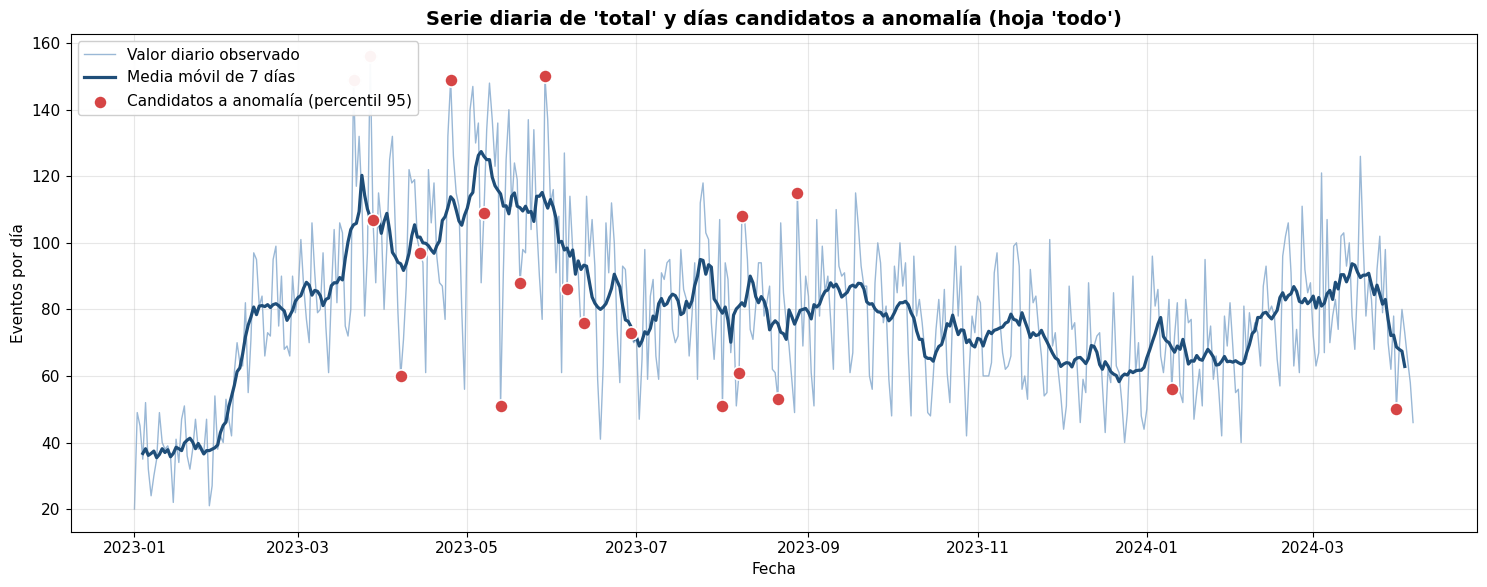

20 días marcados como candidatos a anomalía.
Note que hay puntos rojos ARRIBA y ABAJO de la línea azul:
un día con muchos MENOS eventos de los esperados también es una anomalía.


In [22]:
anomalias = resultados[resultados["es_anomalia"] == 1]

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(df["fecha"], df[VARIABLE_OBJETIVO],
        color="#9ab8d6", lw=1.0, label="Valor diario observado", zorder=1)
ax.plot(df["fecha"], df["media_movil_7"],
        color="#1f4e79", lw=2.3, label="Media móvil de 7 días", zorder=2)

ax.scatter(anomalias["fecha"], anomalias["observado"],
           color="#d64545", s=90, zorder=3, edgecolor="white", linewidth=1.2,
           label=f"Candidatos a anomalía (percentil {PERCENTIL_UMBRAL})")

ax.set_title(f"Serie diaria de '{VARIABLE_OBJETIVO}' y días candidatos a anomalía (hoja '{HOJA}')")
ax.set_xlabel("Fecha")
ax.set_ylabel("Eventos por día")
ax.legend(loc="upper left", framealpha=0.95)
plt.tight_layout()
plt.show()

print(f"{len(anomalias)} días marcados como candidatos a anomalía.")
print("Note que hay puntos rojos ARRIBA y ABAJO de la línea azul:")
print("un día con muchos MENOS eventos de los esperados también es una anomalía.")

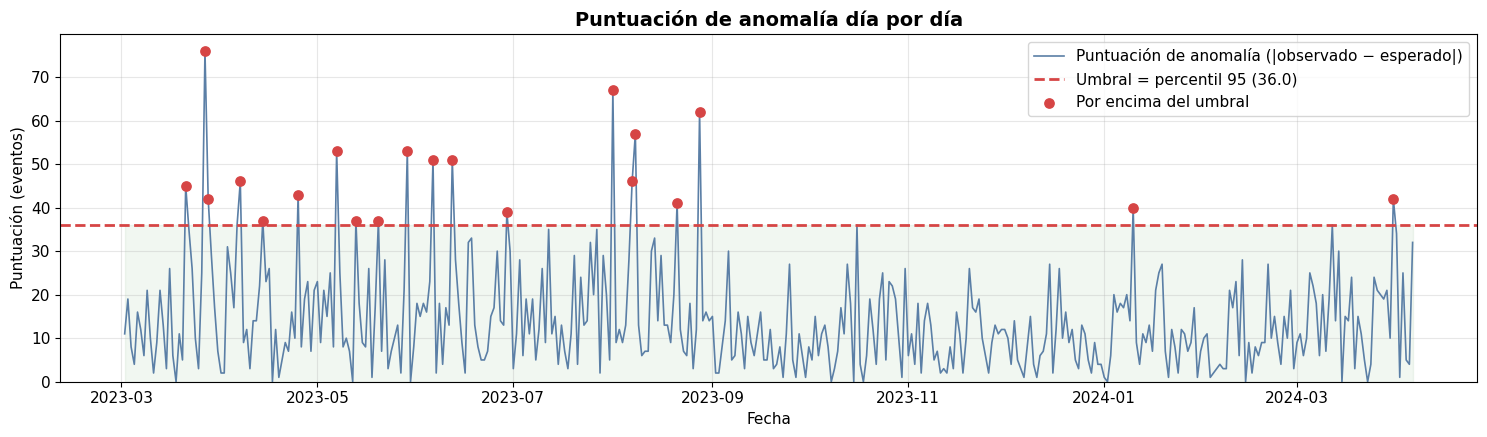

In [23]:
fig, ax = plt.subplots(figsize=(15, 4.5))

ax.plot(resultados["fecha"], resultados["anomaly_score"],
        color="#5b7fa6", lw=1.2, label="Puntuación de anomalía (|observado − esperado|)")
ax.axhline(umbral, color="#d64545", linestyle="--", lw=2,
           label=f"Umbral = percentil {PERCENTIL_UMBRAL} ({umbral:.1f})")
ax.scatter(anomalias["fecha"], anomalias["anomaly_score"],
           color="#d64545", s=45, zorder=3, label="Por encima del umbral")

ax.fill_between(resultados["fecha"], 0, umbral, color="#8fbf8f", alpha=0.12)

ax.set_title("Puntuación de anomalía día por día")
ax.set_xlabel("Fecha")
ax.set_ylabel("Puntuación (eventos)")
ax.set_ylim(bottom=0)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 12. Tabla de investigación de anomalías

Este es **el producto que se lleva el equipo de vigilancia a la reunión**. La idea es pasar de:

> *"el algoritmo encontró una anomalía"*

a:

> *"¿qué ocurrió ese día?"*

Cada fila es una pregunta abierta: ¿fue un festivo? ¿un puente? ¿hubo un cambio en el
registro? ¿estaba el aire especialmente contaminado? ¿llovió muchísimo?

In [24]:
N_REVISAR = 15

columnas_tabla = ["fecha", "nombre_dia", "observado", "esperado", "diferencia",
                  "anomaly_score", "pm10", "pm2.5", "temperatura", "precipitacion"]

tabla_investigacion = (
    resultados[resultados["es_anomalia"] == 1]
    .sort_values("anomaly_score", ascending=False)
    .head(N_REVISAR)[columnas_tabla]
    .reset_index(drop=True)
)

tabla_investigacion["fecha"] = tabla_investigacion["fecha"].dt.strftime("%Y-%m-%d")
tabla_investigacion = tabla_investigacion.round(1)
tabla_investigacion.columns = ["Fecha", "Día", "Observado", "Esperado", "Diferencia",
                               "Puntuación", "PM10", "PM2.5", "Temp. (°C)", "Precip. (mm)"]

print(f"LOS {N_REVISAR} DÍAS QUE MÁS SE ALEJARON DE LO ESPERADO — variable '{VARIABLE_OBJETIVO}'")
tabla_investigacion

LOS 15 DÍAS QUE MÁS SE ALEJARON DE LO ESPERADO — variable 'total'


,Fecha,Día,Observado,Esperado,Diferencia,Puntuación,PM10,PM2.5,Temp. (°C),Precip. (mm)
0,2023-03-27,Lunes,156.0,80.0,76.0,76.0,42.5,28.8,15.4,1.5
1,2023-08-01,Martes,51.0,118.0,-67.0,67.0,13.8,7.6,13.8,2.5
2,2023-08-28,Lunes,115.0,53.0,62.0,62.0,24.5,11.7,15.6,0.0
3,2023-08-08,Martes,108.0,51.0,57.0,57.0,21.2,8.9,15.4,0.0
4,2023-05-29,Lunes,150.0,97.0,53.0,53.0,37.4,17.9,15.2,2.2
5,2023-05-07,Domingo,109.0,56.0,53.0,53.0,21.4,9.8,16.5,0.0
6,2023-06-12,Lunes,76.0,127.0,-51.0,51.0,12.8,6.0,14.9,0.0
7,2023-06-06,Martes,86.0,137.0,-51.0,51.0,15.5,5.5,15.6,0.1
8,2023-04-07,Viernes,60.0,106.0,-46.0,46.0,23.1,16.0,15.0,0.8
9,2023-08-07,Lunes,61.0,107.0,-46.0,46.0,10.9,6.1,15.1,0.8


In [25]:
# ¿Los días candidatos tienden a ser de más o de menos eventos que lo esperado?
por_encima = int((anomalias["diferencia"] > 0).sum())
por_debajo = int((anomalias["diferencia"] < 0).sum())

print(f"Días con MÁS eventos de los esperados  : {por_encima}")
print(f"Días con MENOS eventos de los esperados: {por_debajo}")
print("\nDías de la semana más frecuentes entre los candidatos:")
print(anomalias["nombre_dia"].value_counts().to_string())
print("\n💡 Para discutir en clase: ¿alguna de estas fechas coincide con un festivo,")
print("   un puente o una fecha especial del calendario colombiano?")

Días con MÁS eventos de los esperados  : 9
Días con MENOS eventos de los esperados: 11

Días de la semana más frecuentes entre los candidatos:
nombre_dia
Martes       6
Lunes        6
Viernes      2
Domingo      2
Sábado       2
Jueves       1
Miércoles    1

💡 Para discutir en clase: ¿alguna de estas fechas coincide con un festivo,
   un puente o una fecha especial del calendario colombiano?


## 13. Salud y ambiente: mirar juntos, sin concluir de más

Ahora comparamos qué estaba pasando con el aire y el clima **los días candidatos a
anomalía** frente a **el resto de los días**.

> ### ⚠️ Advertencia que debe permanecer siempre en este análisis
>
> **Una coincidencia temporal no demuestra causalidad. Esta exploración sirve para generar
> preguntas que posteriormente requieren análisis epidemiológico.**
>
> Razones para ser prudentes: los efectos ambientales sobre la salud suelen aparecer con
> **días de retraso**, muchas variables se mueven juntas (contaminación, clima, día de la
> semana, festivos), y aquí estamos mirando **pocos días**.

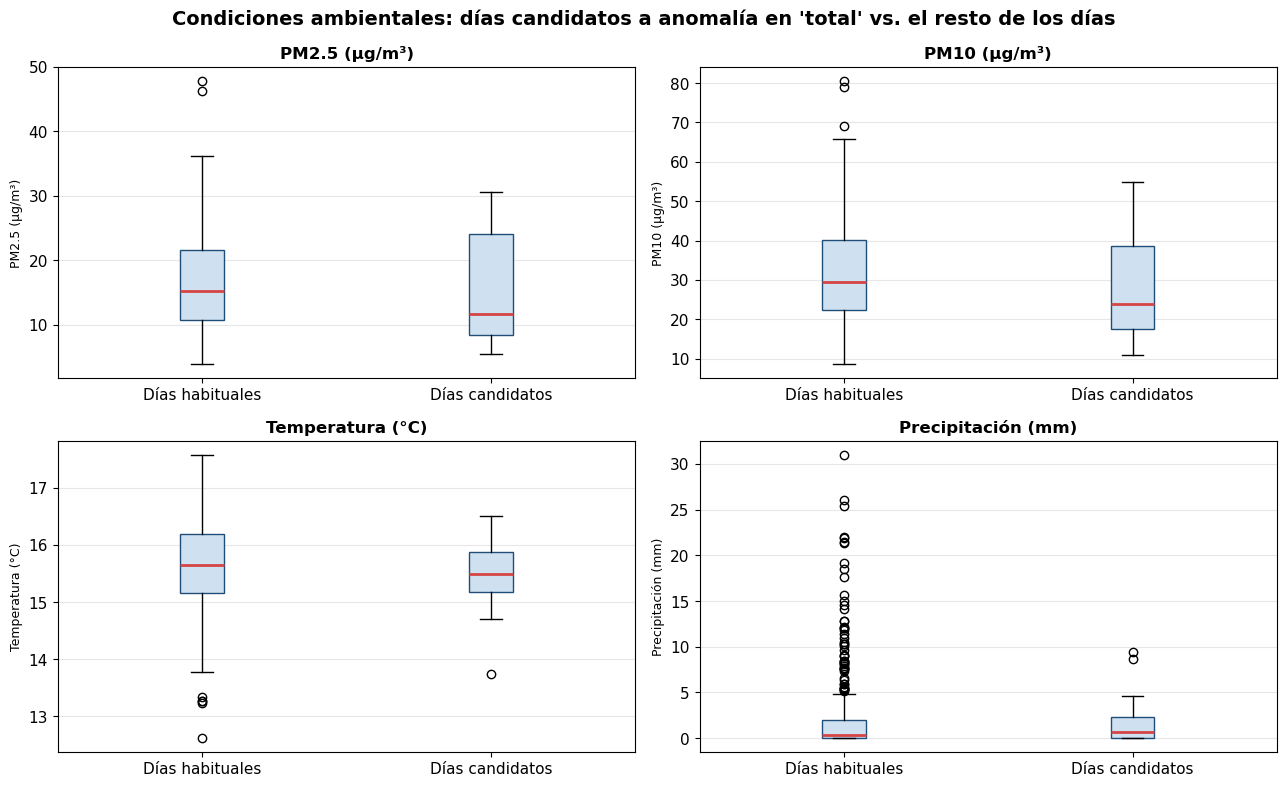

In [26]:
variables_ambientales = ["pm2.5", "pm10", "temperatura", "precipitacion"]
etiquetas = {"pm2.5": "PM2.5 (µg/m³)", "pm10": "PM10 (µg/m³)",
             "temperatura": "Temperatura (°C)", "precipitacion": "Precipitación (mm)"}

grupo_anomalo = resultados[resultados["es_anomalia"] == 1]
grupo_normal  = resultados[resultados["es_anomalia"] == 0]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax, variable in zip(axes.ravel(), variables_ambientales):
    ax.boxplot([grupo_normal[variable].dropna(), grupo_anomalo[variable].dropna()],
               tick_labels=["Días habituales", "Días candidatos"],
               patch_artist=True,
               boxprops=dict(facecolor="#cfe0f0", color="#1f4e79"),
               medianprops=dict(color="#d64545", linewidth=2))
    ax.set_title(etiquetas[variable], fontsize=12)
    ax.set_ylabel(etiquetas[variable], fontsize=9)
    ax.grid(axis="x", visible=False)

fig.suptitle(f"Condiciones ambientales: días candidatos a anomalía en '{VARIABLE_OBJETIVO}' "
             f"vs. el resto de los días", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [27]:
comparacion = pd.DataFrame({
    "Días habituales": grupo_normal[variables_ambientales].mean(),
    "Días candidatos": grupo_anomalo[variables_ambientales].mean(),
}).round(2)
comparacion["Diferencia"] = (comparacion["Días candidatos"] - comparacion["Días habituales"]).round(2)
comparacion.index = [etiquetas[v] for v in comparacion.index]

print("PROMEDIOS AMBIENTALES POR GRUPO")
print(comparacion.to_string())
print("\n" + "=" * 70)
print("⚠️  Una coincidencia temporal NO demuestra causalidad.")
print("    Esta exploración sirve para generar preguntas que posteriormente")
print("    requieren análisis epidemiológico.")
print("=" * 70)

PROMEDIOS AMBIENTALES POR GRUPO
                    Días habituales  Días candidatos  Diferencia
PM2.5 (µg/m³)                 16.70            15.69       -1.01
PM10 (µg/m³)                  32.07            28.86       -3.21
Temperatura (°C)              15.64            15.48       -0.16
Precipitación (mm)             2.27             1.84       -0.43

⚠️  Una coincidencia temporal NO demuestra causalidad.
    Esta exploración sirve para generar preguntas que posteriormente
    requieren análisis epidemiológico.


## 14. Segundo ejemplo: la misma lógica aplicada al PM2.5

El procedimiento que aprendimos **no es exclusivo de los datos de salud**. Sirve para
cualquier serie de tiempo. Vamos a aplicarlo tal cual a una variable ambiental: el **PM2.5**.

Para no repetir código, empaquetamos los mismos pasos de las secciones 8 a 11 en dos
funciones cortas.

In [28]:
def detectar_anomalias(datos, variable, k=ESTACIONALIDAD,
                       dias_aprendizaje=DIAS_APRENDIZAJE, percentil=PERCENTIL_UMBRAL):
    """Repite los pasos del taller para cualquier variable diaria.

    Devuelve la tabla de resultados (observado, esperado, puntuación, marca) y el umbral.
    """
    serie_var = TimeSeries.from_dataframe(datos, time_col="fecha",
                                          value_cols=variable, freq="D")

    modelo_var = NaiveSeasonal(K=k)
    esperado = modelo_var.historical_forecasts(
        serie_var, start=dias_aprendizaje, start_format="position",
        forecast_horizon=1, stride=1, retrain=True,
        last_points_only=True, verbose=False,
    )
    observado = serie_var.slice_intersect(esperado)

    puntuaciones = NormScorer(ord=1).score_from_prediction(observado, esperado)

    tabla = pd.DataFrame({
        "fecha":         puntuaciones.time_index,
        "observado":     observado.values().ravel(),
        "esperado":      esperado.values().ravel(),
        "anomaly_score": puntuaciones.values().ravel(),
    })
    tabla["diferencia"] = tabla["observado"] - tabla["esperado"]

    umbral_var = np.percentile(tabla["anomaly_score"], percentil)
    tabla["es_anomalia"] = (tabla["anomaly_score"] > umbral_var).astype(int)
    return tabla, umbral_var


def graficar_anomalias(datos, tabla, variable, titulo=None):
    """Dibuja la serie, su media móvil de 7 días y los días candidatos a anomalía."""
    marcados = tabla[tabla["es_anomalia"] == 1]

    fig, ax = plt.subplots(figsize=(15, 5.5))
    ax.plot(datos["fecha"], datos[variable], color="#9ab8d6", lw=1.0,
            label="Valor diario observado")
    ax.plot(datos["fecha"], datos[variable].rolling(7, center=True).mean(),
            color="#1f4e79", lw=2.3, label="Media móvil de 7 días")
    ax.scatter(marcados["fecha"], marcados["observado"], color="#d64545", s=80,
               zorder=3, edgecolor="white", linewidth=1.1, label="Candidatos a anomalía")

    ax.set_title(titulo or f"Serie diaria de '{variable}' y días candidatos a anomalía")
    ax.set_xlabel("Fecha")
    ax.set_ylabel(variable)
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()


print("✓ Funciones listas para reutilizar")

✓ Funciones listas para reutilizar


In [29]:
# Comprobación: la función reproduce exactamente el resultado que construimos paso a paso
verificacion, umbral_verificacion = detectar_anomalias(df, VARIABLE_OBJETIVO)

print(f"Anomalías paso a paso   : {int(resultados['es_anomalia'].sum())}")
print(f"Anomalías con la función: {int(verificacion['es_anomalia'].sum())}")
print(f"Umbrales iguales        : {np.isclose(umbral, umbral_verificacion)}")

Anomalías paso a paso   : 20
Anomalías con la función: 20
Umbrales iguales        : True


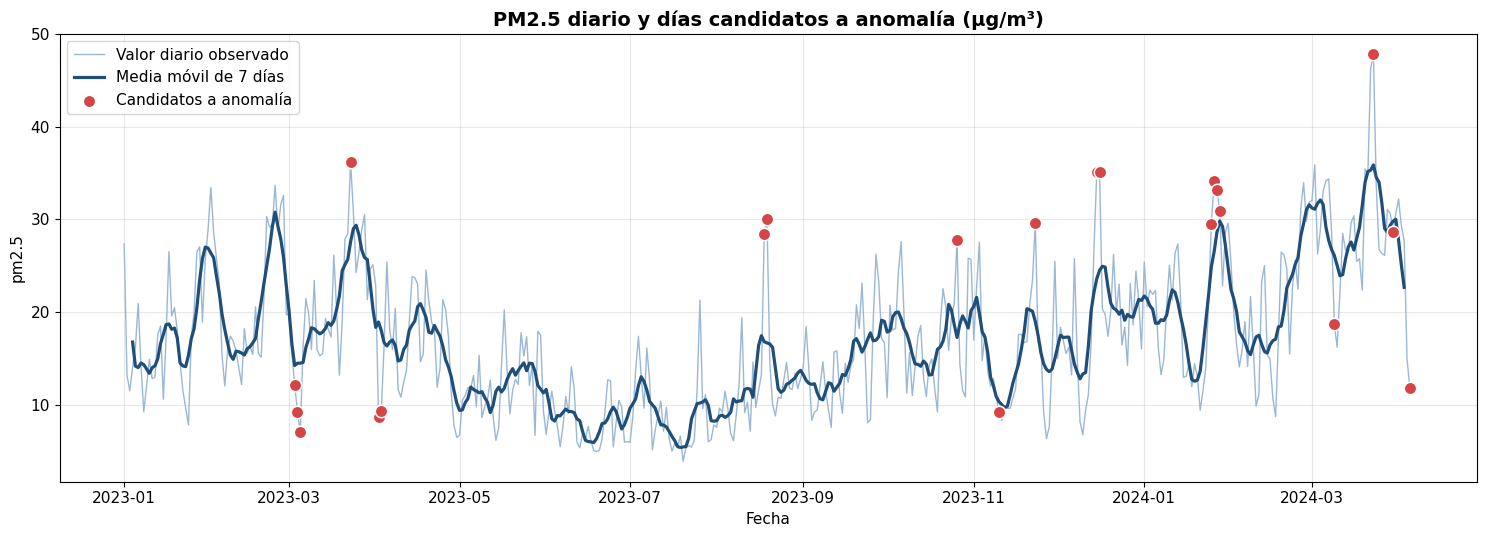

Umbral (percentil 95): 17.2 µg/m³
Días candidatos: 21



,Fecha,Día,PM2.5 observado,PM2.5 esperado,Diferencia,Puntuación
0,2023-12-16,Sábado,35.1,8.2,26.8,26.8
1,2023-03-05,Domingo,7.0,31.5,-24.5,24.5
2,2024-01-28,Domingo,30.9,9.4,21.5,21.5
3,2023-03-03,Viernes,12.2,33.7,-21.5,21.5
4,2024-01-27,Sábado,33.2,13.0,20.2,20.2
5,2023-12-15,Viernes,35.1,15.1,20.1,20.1
6,2023-08-19,Sábado,30.1,10.3,19.8,19.8
7,2024-01-26,Viernes,34.1,14.4,19.7,19.7
8,2023-04-03,Lunes,9.3,28.8,-19.5,19.5
9,2023-03-04,Sábado,9.3,28.8,-19.5,19.5


In [30]:
tabla_pm25, umbral_pm25 = detectar_anomalias(df, "pm2.5")

graficar_anomalias(df, tabla_pm25, "pm2.5",
                   titulo="PM2.5 diario y días candidatos a anomalía (µg/m³)")

print(f"Umbral (percentil {PERCENTIL_UMBRAL}): {umbral_pm25:.1f} µg/m³")
print(f"Días candidatos: {int(tabla_pm25['es_anomalia'].sum())}\n")

top_pm25 = (tabla_pm25.sort_values("anomaly_score", ascending=False)
            .head(10)
            .merge(df[["fecha", "nombre_dia"]], on="fecha", how="left"))
top_pm25["fecha"] = top_pm25["fecha"].dt.strftime("%Y-%m-%d")
top_pm25 = top_pm25[["fecha", "nombre_dia", "observado", "esperado",
                     "diferencia", "anomaly_score"]].round(1)
top_pm25.columns = ["Fecha", "Día", "PM2.5 observado", "PM2.5 esperado",
                    "Diferencia", "Puntuación"]
top_pm25

### ¿Tiene el PM2.5 el mismo patrón semanal que las consultas?

Antes de sacar conclusiones, comparemos **cuánto pesa el día de la semana** en cada una de
las dos series. Medimos la diferencia entre el día más alto y el más bajo, expresada como
porcentaje del promedio de la serie.

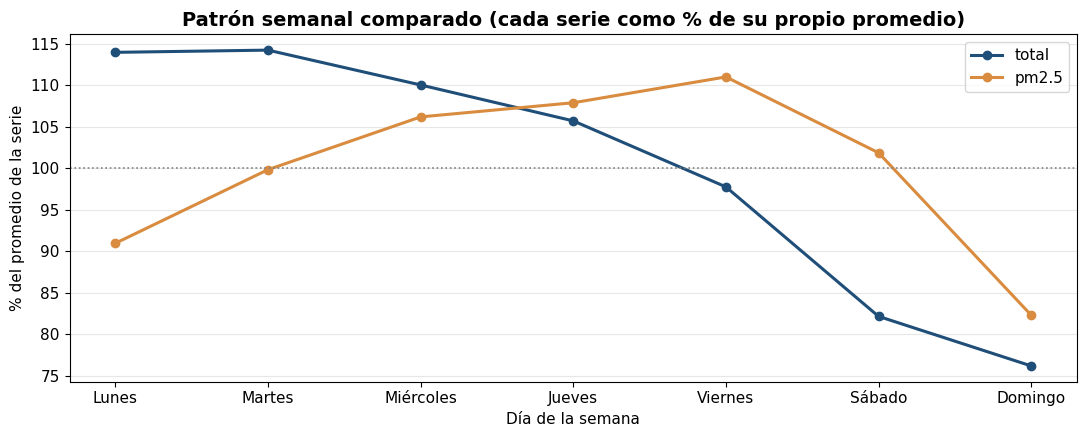

Peso del día de la semana en 'total': 38% del promedio
Peso del día de la semana en 'pm2.5'  : 29% del promedio


In [31]:
def amplitud_semanal(variable):
    """Diferencia entre el día más alto y el más bajo, como % del promedio de la serie."""
    promedios = df.groupby("dia_semana")[variable].mean()
    return 100 * (promedios.max() - promedios.min()) / df[variable].mean()


fig, ax = plt.subplots(figsize=(11, 4.5))

for variable, color in [(VARIABLE_OBJETIVO, "#1f4e79"), ("pm2.5", "#d98c3f")]:
    promedios = df.groupby("dia_semana")[variable].mean()
    # Escala relativa: cada serie se expresa como % de su propio promedio
    ax.plot(DIAS_ES, 100 * promedios.values / df[variable].mean(),
            marker="o", lw=2.2, color=color, label=variable)

ax.axhline(100, color="gray", linestyle=":", lw=1.2)
ax.set_title("Patrón semanal comparado (cada serie como % de su propio promedio)")
ax.set_xlabel("Día de la semana")
ax.set_ylabel("% del promedio de la serie")
ax.legend(loc="best")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

print(f"Peso del día de la semana en '{VARIABLE_OBJETIVO}': {amplitud_semanal(VARIABLE_OBJETIVO):.0f}% del promedio")
print(f"Peso del día de la semana en 'pm2.5'  : {amplitud_semanal('pm2.5'):.0f}% del promedio")

### ¿Qué aprendimos con este segundo ejemplo?

El concepto de anomalía **es el mismo** para una variable sanitaria y para una ambiental:
siempre es *observado vs. esperado*. Cambian los datos, no el razonamiento.

Pero el gráfico anterior muestra una diferencia importante: el PM2.5 **también** tiene un
ritmo semanal (el tráfico y la actividad industrial sí saben qué día es), aunque **menos
marcado** y con otra forma: en las consultas el punto bajo es el domingo, mientras que en
el PM2.5 el aire más limpio aparece los fines de semana y el más cargado entre semana.

Como el patrón semanal pesa menos, la regla del "mismo día de la semana anterior" es una
referencia **más floja** para el PM2.5: le quedan muchas puntuaciones altas que en realidad
son solo la variabilidad normal del aire.

> Lección para la vigilancia: **el modelo de referencia debe elegirse según el
> comportamiento de cada serie**, no aplicarse a ciegas.

## 15. (Opcional) Comparar las dos hojas del archivo

El Excel trae dos versiones de la misma serie: `todo` y `sin chapinero`. Comparar ambas
permite preguntarse algo muy concreto de la operación:

> **¿Los días que marcamos como raros dependen de una sola localidad, o son un fenómeno
> de toda la red centinela?**

Esta sección es complementaria: no es el tema central del taller.

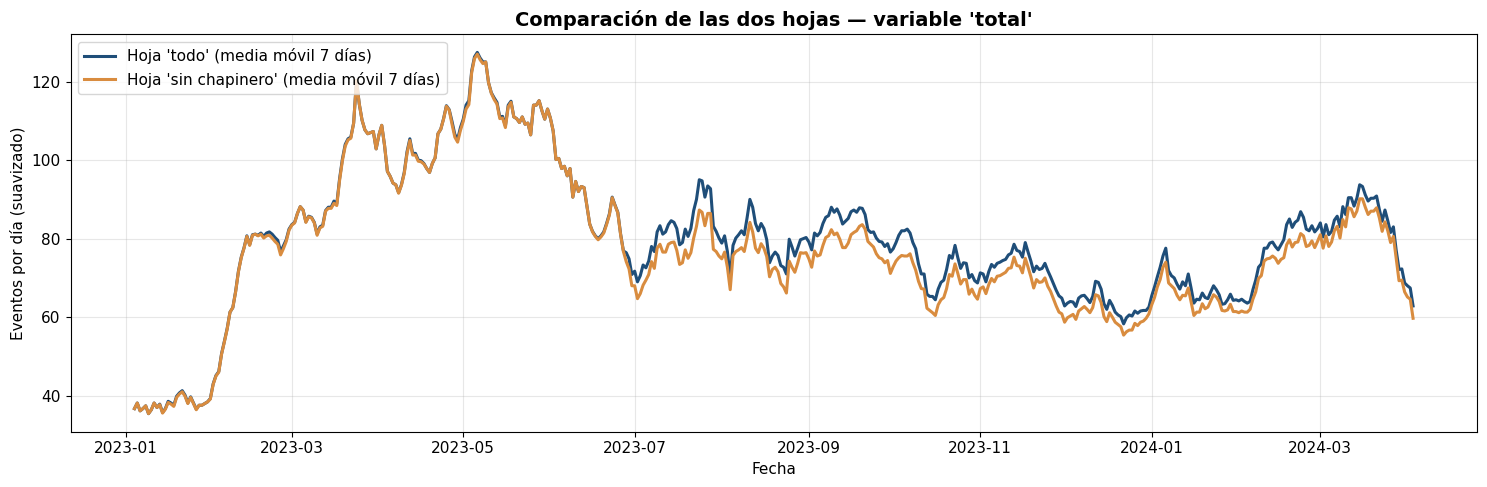

Promedio diario 'todo'          : 79.4
Promedio diario 'sin chapinero' : 76.9
Diferencia promedio             : 2.5 eventos/día


In [32]:
df_todo = cargar_hoja("todo")
df_sin  = cargar_hoja("sin chapinero")

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df_todo["fecha"], df_todo["total"].rolling(7, center=True).mean(),
        color="#1f4e79", lw=2.2, label="Hoja 'todo' (media móvil 7 días)")
ax.plot(df_sin["fecha"], df_sin["total"].rolling(7, center=True).mean(),
        color="#d98c3f", lw=2.2, label="Hoja 'sin chapinero' (media móvil 7 días)")

ax.set_title("Comparación de las dos hojas — variable 'total'")
ax.set_xlabel("Fecha")
ax.set_ylabel("Eventos por día (suavizado)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

print(f"Promedio diario 'todo'          : {df_todo['total'].mean():.1f}")
print(f"Promedio diario 'sin chapinero' : {df_sin['total'].mean():.1f}")
print(f"Diferencia promedio             : {(df_todo['total'] - df_sin['total']).mean():.1f} eventos/día")

In [33]:
anom_todo, _ = detectar_anomalias(df_todo, "total")
anom_sin,  _ = detectar_anomalias(df_sin,  "total")

fechas_todo = set(anom_todo.loc[anom_todo["es_anomalia"] == 1, "fecha"])
fechas_sin  = set(anom_sin.loc[anom_sin["es_anomalia"] == 1, "fecha"])
comunes     = sorted(fechas_todo & fechas_sin)

print(f"Días candidatos en 'todo'          : {len(fechas_todo)}")
print(f"Días candidatos en 'sin chapinero' : {len(fechas_sin)}")
print(f"Días candidatos en AMBAS hojas     : {len(comunes)}")
print(f"\nCoincidencia: {100 * len(comunes) / max(len(fechas_todo), 1):.0f}% de los días marcados")
print("\nFechas que aparecen en las dos hojas:")
print(", ".join(f"{f:%Y-%m-%d}" for f in comunes[:12]))
print("\n💡 Un día marcado en AMBAS hojas difícilmente se explica por una sola localidad.")

Días candidatos en 'todo'          : 20
Días candidatos en 'sin chapinero' : 19
Días candidatos en AMBAS hojas     : 18

Coincidencia: 90% de los días marcados

Fechas que aparecen en las dos hojas:
2023-03-21, 2023-03-27, 2023-03-28, 2023-04-07, 2023-04-25, 2023-05-07, 2023-05-13, 2023-05-20, 2023-05-29, 2023-06-06, 2023-06-12, 2023-06-29

💡 Un día marcado en AMBAS hojas difícilmente se explica por una sola localidad.


## 16. Actividad para los participantes

Ninguno de estos ejercicios exige programación avanzada: casi todos se resuelven
**cambiando un número en la sección 3 y volviendo a ejecutar el cuaderno**
(menú *Kernel → Restart & Run All*).

---

**Ejercicio 1 — Cambiar de evento**
En la sección 3 cambie `VARIABLE_OBJETIVO = "total"` por `VARIABLE_OBJETIVO = "resp"` y
ejecute todo de nuevo.
→ ¿Los días candidatos son los mismos que con `total`? ¿Qué cambió en el patrón semanal?

**Ejercicio 2 — Mover el umbral**
Cambie `PERCENTIL_UMBRAL = 95` por `97`.
→ ¿Cuántos días quedan marcados ahora? ¿Cuáles desaparecieron? Si su equipo solo puede
revisar 5 días al año, ¿qué percentil usaría?

**Ejercicio 3 — Tres días para investigar**
De la tabla de la sección 12, escoja **tres fechas** y averigüe qué ocurrió:
¿festivo?, ¿puente?, ¿jornada de vacunación?, ¿falla en el sistema de registro?

**Ejercicio 4 — Mirar el aire**
Para esas mismas tres fechas, revise en la tabla los valores de **PM2.5** y **PM10**.
→ ¿Estaban altos, bajos o normales? Escriba **una pregunta de investigación**, no una
conclusión.

**Ejercicio 5 — La pregunta conceptual**
Explique con sus palabras, a alguien que no sepa estadística, **por qué un valor alto no es
necesariamente una anomalía**. Use como ejemplo un lunes y un domingo.

**Ejercicio 6 — Fin de semana contra inicio de semana**
Con el gráfico de barras de la sección 6, compare **sábado y domingo** con **lunes y martes**.
→ ¿Cuántos eventos de diferencia hay? ¿Qué implica esto para programar el personal del
servicio? ¿Y para interpretar un "pico" que ocurre un lunes?

**Ejercicio 7 (opcional) — Cambiar de hoja**
Cambie `HOJA = "todo"` por `HOJA = "sin chapinero"` y ejecute todo.
→ ¿Se mantienen las mismas fechas candidatas?

## 17. Conclusión: el camino completo en una sola imagen

Todo lo que hicimos en este cuaderno cabe en una sola secuencia. Es el esquema que
conviene recordar cuando se aplique a cualquier otra serie de vigilancia.

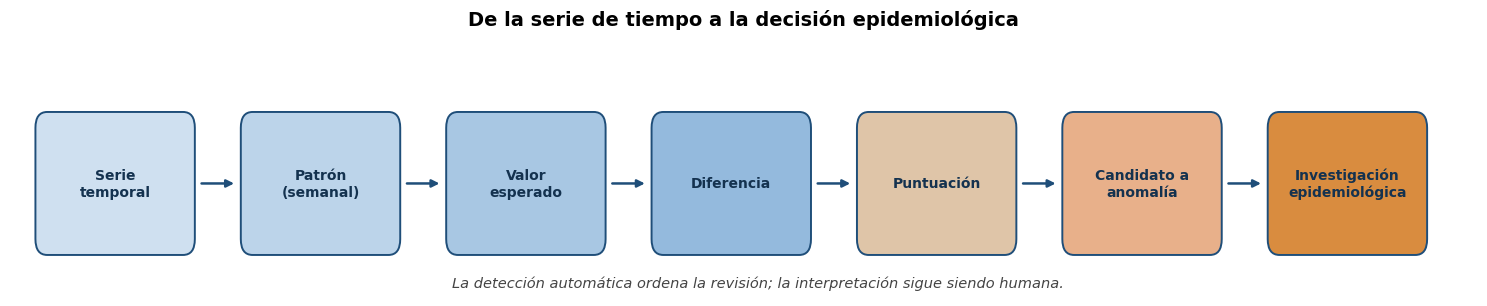

In [34]:
from matplotlib.patches import FancyBboxPatch

pasos = ["Serie\ntemporal", "Patrón\n(semanal)", "Valor\nesperado", "Diferencia",
         "Puntuación", "Candidato a\nanomalía", "Investigación\nepidemiológica"]
colores_pasos = ["#cfe0f0", "#bcd4ea", "#a8c7e3", "#94badd", "#dfc5a8", "#e8b08a", "#d98c3f"]

fig, ax = plt.subplots(figsize=(15, 3.2))
ancho, alto, sep = 1.55, 1.0, 0.55

for i, (paso, color) in enumerate(zip(pasos, colores_pasos)):
    x = i * (ancho + sep)
    ax.add_patch(FancyBboxPatch((x, 0), ancho, alto,
                                boxstyle="round,pad=0.04,rounding_size=0.12",
                                facecolor=color, edgecolor="#1f4e79", linewidth=1.4))
    ax.text(x + ancho / 2, alto / 2, paso, ha="center", va="center",
            fontsize=10, fontweight="bold", color="#14324f")
    if i < len(pasos) - 1:
        ax.annotate("", xy=(x + ancho + sep - 0.08, alto / 2), xytext=(x + ancho + 0.08, alto / 2),
                    arrowprops=dict(arrowstyle="-|>", color="#1f4e79", linewidth=1.8))

ax.set_xlim(-0.3, len(pasos) * (ancho + sep))
ax.set_ylim(-0.35, alto + 0.55)
ax.axis("off")
ax.set_title("De la serie de tiempo a la decisión epidemiológica", fontsize=14,
             fontweight="bold", pad=14)
ax.text(ax.get_xlim()[1] / 2, -0.28,
        "La detección automática ordena la revisión; la interpretación sigue siendo humana.",
        ha="center", fontsize=10.5, style="italic", color="#444444")
plt.tight_layout()
plt.show()

### Lo que hay que llevarse del taller

1. **Una serie de tiempo es una variable observada repetidamente en el tiempo**, y su orden
   es información valiosa que no se puede revolver.

2. **No todos los días se comportan igual.** En estos datos, el día de la semana explica
   una parte muy grande de la variación. Ignorarlo produce falsas alarmas los lunes y
   ceguera los domingos.

3. **Una anomalía no es un valor alto: es un valor inesperado.** Siempre hace falta un
   *valor esperado* con el cual comparar.

4. **El modelo puede ser muy sencillo.** Comparar con el mismo día de la semana anterior ya
   permite construir un sistema de alerta entendible por todo el equipo. Empiece simple;
   complique solo si hace falta.

5. **El umbral es una decisión, no un descubrimiento.** Debe escribirse, justificarse y
   ajustarse a la capacidad real de respuesta del equipo.

6. **La coincidencia temporal no es causalidad.** El vínculo entre ambiente y salud requiere
   diseños epidemiológicos apropiados, no solo puntos rojos en un gráfico.

---

> ### 🎯 Mensaje final
>
> **La detección automática de anomalías es una herramienta de apoyo: ayuda a decidir qué
> días revisar primero. No reemplaza la interpretación epidemiológica, el conocimiento del
> territorio ni la verificación de la calidad del dato.**
>
> El algoritmo señala. **Las personas interpretan.**

## 18. Para profundizar (fuera del alcance de este taller)

Estos temas **no son necesarios** para lo que hicimos hoy, pero son el camino natural para
quien quiera seguir. Se dejan como referencia, sin código que ejecutar.

**Diagnóstico estadístico de la serie**
- **ACF y PACF**: gráficos que muestran cuánto se parece la serie a sí misma con distintos
  rezagos. Confirmarían numéricamente el patrón de 7 días que vimos con el gráfico de barras.
- **Prueba ADF** (Dickey-Fuller aumentada): evalúa si la serie es estacionaria, requisito de
  varios modelos clásicos.
- **Descomposición** en tendencia + estacionalidad + residuo.

**Mejores valores esperados**
- **Suavizamiento exponencial (Holt-Winters)** y **SARIMA / AutoARIMA**: modelan nivel,
  tendencia y estacionalidad de manera conjunta.
- **Modelos con variables externas** (SARIMAX): permiten incluir PM2.5, temperatura o
  festivos como predictores, que es el paso natural para la pregunta ambiental.
- **Modelos de aprendizaje automático** y **modelos fundacionales** de pronóstico.

**Más herramientas de `darts.ad`**
- Otros *scorers*: `KMeansScorer`, `WassersteinScorer`, `PyODScorer`.
- *Detectors* como `QuantileDetector` y `ThresholdDetector`, que automatizan el paso del
  umbral.
- `AnomalyModel`, que une modelo + scorer + detector en un solo objeto.
- Métricas de evaluación de anomalías (`eval_metric_from_scores`) cuando se dispone de una
  lista verificada de eventos reales.

**Métodos propios de la vigilancia epidemiológica**
- **Canal endémico** y corredores endémicos.
- **Algoritmo de Farrington** y **EARS/CUSUM**, usados por sistemas nacionales de vigilancia.
- Ajuste por población, por días festivos y por retrasos en la notificación.

```python
# Ejemplo de a dónde seguir (no ejecutar en este taller):
# from darts.ad import QuantileDetector, ForecastingAnomalyModel
# from darts.models import ExponentialSmoothing
```